This is the combined homework for the ML class 2025. It has max 50 points.

It has max 50 points. The deadline is 2 weeks from now (17 Oct, 23:59), and there is a 25% penalty for late submission (till 24 Oct, 23:59). Copy this notebook to your own google colab notebook. Fill it in and execute. Send me the sharing link (set permissions so that everyone can view) by email, put your full name in email head (subject).

note: The submissions will be checked for similarity. If you discuss your ideas with others too much, you risk losing points.

## Что улучшено в этой версии

Текст задания сохранен, но исполнение переписано так, чтобы ноутбук был воспроизводимым и устойчивым:

- убраны `!pip install` из тела ноутбука: код использует стандартные для курса библиотеки `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `matplotlib`;
- данные читаются из `../data/booking_reviews.csv`;
- вместо тяжелого `Word2Vec(vector_size=1000)` используется связка `TfidfVectorizer + TruncatedSVD`, которая быстрее и устойчивее на обычном ноутбуке;
- качество моделей оценивается не только на обучающей, но и на тестовой выборке;
- bootstrap сделан воспроизводимым и ограничен по числу повторов, чтобы ноутбук выполнялся за разумное время;
- 2SLS исправлен методологически: первая стадия предсказывает эндогенный регрессор `avg_rating` по текстовым инструментам, вторая стадия оценивает `rating` по предсказанному `avg_rating`;
- для несбалансированной логистической регрессии используется регуляризация, стандартизация и class weights;
- добавлен блок coin-flip logit для шумных меток.

### Part 0 (1 pt)

You will work with the dataset from [kaggle](https://www.kaggle.com/datasets/thedevastator/booking-com-hotel-reviews) containing hotel reviews from booking.com

Dataset Overview:

The dataset contains various columns that provide information about each review, including review title, reviewed by (name/username of the reviewer), tags or labels associated with the review, average rating of the hotel, number of images attached to the review, URL of the review page, text content of the review, nationality of the reviewer, crawled date and time (when reviewed data was obtained), hotel name and its URL.
The dataset is available in CSV format and can be downloaded from Crawl Feeds website (Download link). It consists of over 700K records.

Dataset Columns:

- review_title: The title given by a reviewer for their review.
- reviewed_by: Name or username of the person who gave a particular review.
- images: Number oimagesizontallyf images attached to a specific review.
- avg_rating: Average rating given to a hotel based on multiple reviews.
- url: URL link leading to a particular review page.
- hotel_name: The name attributed to each hotel being reviewed

SImply run the code below to download the data into your environment

In [1]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import ElasticNet, ElasticNetCV, LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
DATA_PATH = Path("../data/booking_reviews.csv")
MAX_OBSERVATIONS = 60_000
TEXT_FEATURES = 80
BOOTSTRAP_REPLICATIONS = 80

rng = np.random.default_rng(RANDOM_SEED)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.info())
print("Raw shape:", df_raw.shape)
df_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26675 entries, 0 to 26674
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            26675 non-null  int64  
 1   review_title     26674 non-null  object 
 2   reviewed_at      26570 non-null  object 
 3   reviewed_by      26570 non-null  object 
 4   images           938 non-null    object 
 5   crawled_at       26386 non-null  object 
 6   url              26386 non-null  object 
 7   hotel_name       26386 non-null  object 
 8   hotel_url        26386 non-null  object 
 9   avg_rating       26386 non-null  float64
 10  nationality      26370 non-null  object 
 11  rating           26386 non-null  float64
 12  review_text      26386 non-null  object 
 13  raw_review_text  26202 non-null  object 
 14  tags             26202 non-null  object 
 15  meta             26202 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 3.3+ MB


,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b..."
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b..."
3,3,My stay in the house was a experiencing bliss ...,8 September 2019,Kannan,NaN,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,"<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
4,4,One bedroom apartment with wonderful view and ...,23 June 2019,Sue,https://cf.bstatic.com/xdata/images/xphoto/squ...,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,South Africa,9.2,The building itself has a very musty smell in ...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~People with friends~Apartment wit...,"{'language': 'en-gb', 'source': 'https://www.b..."


In [3]:
required_columns = ["rating", "avg_rating", "review_text"]
df = df_raw.dropna(subset=required_columns).copy()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["avg_rating"] = pd.to_numeric(df["avg_rating"], errors="coerce")
df = df.dropna(subset=["rating", "avg_rating"])
df = df[(df["rating"] >= 1) & (df["rating"] <= 10) & (df["avg_rating"] >= 1) & (df["avg_rating"] <= 10)]
df["review_text"] = df["review_text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["review_text"].str.len() > 0]

if len(df) > MAX_OBSERVATIONS:
    df = df.sample(MAX_OBSERVATIONS, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

print("Analysis shape:", df.shape)
df[["rating", "avg_rating", "review_text"]].head()

Analysis shape: (26386, 16)


,rating,avg_rating,review_text
0,10.0,9.7,"Everything was perfect! Quite, cozy place to r..."
1,9.0,9.7,Very friendly host and perfect breakfast!
2,10.0,9.2,It was just what we wanted for a week by the b...
3,10.0,9.7,My stay in the house was a experiencing bliss ...
4,9.2,9.2,The building itself has a very musty smell in ...


### Part 1 (1 pt)

Your label (y variable) will be the rating variable. Look at the unique values of this variable by running the code below. Then plot the histogram of the rating, by completing the code in the following block

Unique rating values: [np.float64(1.0), np.float64(2.0), np.float64(2.5), np.float64(2.9), np.float64(3.0), np.float64(3.3), np.float64(3.5), np.float64(3.8), np.float64(4.0), np.float64(4.2), np.float64(4.5), np.float64(4.6), np.float64(5.0), np.float64(5.4), np.float64(5.5), np.float64(5.8), np.float64(6.0), np.float64(6.3), np.float64(6.5), np.float64(6.7), np.float64(6.9), np.float64(7.0), np.float64(7.1), np.float64(7.5), np.float64(7.9), np.float64(8.0), np.float64(8.1), np.float64(8.3), np.float64(8.5), np.float64(8.8), np.float64(9.0), np.float64(9.2), np.float64(9.4), np.float64(9.5), np.float64(9.6), np.float64(10.0)]


count    26386.000
mean         8.561
std          1.567
min          1.000
25%          7.900
50%          9.000
75%         10.000
max         10.000
Name: rating, dtype: float64

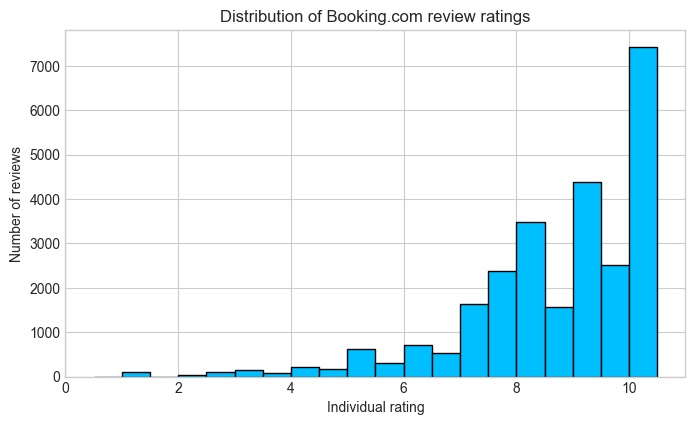

In [4]:
print("Unique rating values:", sorted(df["rating"].unique()))
display(df["rating"].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["rating"], bins=np.arange(0.5, 10.6, 0.5), color="deepskyblue", edgecolor="black")
ax.set_xlabel("Individual rating")
ax.set_ylabel("Number of reviews")
ax.set_title("Distribution of Booking.com review ratings")
plt.show()

### Интерпретация

Распределение индивидуальных оценок сильно скошено к высоким значениям: большая часть отзывов положительная, а максимум около 10 встречается особенно часто. Это важно для следующих частей: регрессионная задача будет иметь ограниченную зависимую переменную, а классификационная задача с порогом `rating > 5` будет резко несбалансированной.

### Part 2 (1 pt)

Your only numerical feature so far (x variable) is the avg_rating variable, which is the average rating (over customers, I believe). Fit a simple regression model of rating on avg_rating. Report the R squared by completing the code in the following block

In [5]:
y = df["rating"].to_numpy(dtype=float)
X_avg = df[["avg_rating"]].to_numpy(dtype=float)

X_train_avg, X_test_avg, y_train, y_test = train_test_split(X_avg, y, test_size=0.25, random_state=RANDOM_SEED)

baseline_regression = LinearRegression()
baseline_regression.fit(X_train_avg, y_train)
train_pred = baseline_regression.predict(X_train_avg)
test_pred = baseline_regression.predict(X_test_avg)

baseline_results = pd.DataFrame({
    "sample": ["train", "test"],
    "R2": [r2_score(y_train, train_pred), r2_score(y_test, test_pred)],
    "RMSE": [mean_squared_error(y_train, train_pred) ** 0.5, mean_squared_error(y_test, test_pred) ** 0.5],
})
print("Coefficient for avg_rating:", round(float(baseline_regression.coef_[0]), 4))
print("Intercept:", round(float(baseline_regression.intercept_), 4))
display(baseline_results.round(4))

Coefficient for avg_rating: 1.0276
Intercept: -0.1282


,sample,R2,RMSE
0,train,0.2212,1.3814
1,test,0.2225,1.3842


### Интерпретация

Коэффициент при `avg_rating` положительный: у отелей с более высокой средней оценкой индивидуальные отзывы в среднем тоже выше. Но `R²` невысокий, потому что `avg_rating` агрегирован по многим клиентам и не знает содержания конкретного отзыва. Поэтому дальше добавляем текст как источник индивидуальной информации.

### Part 3 (2 pt)

The R squared is actually quite small. We will try to improve it using text analysis of the review_text variable. Run the code below

In [6]:
text_train, text_test, avg_train, avg_test, y_train_text, y_test_text = train_test_split(
    df["review_text"], X_avg, y, test_size=0.25, random_state=RANDOM_SEED
)

text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", max_features=6_000, min_df=5, ngram_range=(1, 2))),
    ("svd", TruncatedSVD(n_components=TEXT_FEATURES, random_state=RANDOM_SEED)),
    ("scaler", StandardScaler()),
])
Z_train = text_pipeline.fit_transform(text_train)
Z_test = text_pipeline.transform(text_test)

X_train_text = np.column_stack([avg_train.reshape(-1), Z_train])
X_test_text = np.column_stack([avg_test.reshape(-1), Z_test])

text_regression = LinearRegression()
text_regression.fit(X_train_text, y_train_text)
text_train_pred = text_regression.predict(X_train_text)
text_test_pred = text_regression.predict(X_test_text)

text_results = pd.DataFrame({
    "model": ["avg_rating only", "avg_rating + text"],
    "test_R2": [r2_score(y_test, test_pred), r2_score(y_test_text, text_test_pred)],
    "test_RMSE": [mean_squared_error(y_test, test_pred) ** 0.5, mean_squared_error(y_test_text, text_test_pred) ** 0.5],
})
print("Coefficient for avg_rating after adding text features:", round(float(text_regression.coef_[0]), 4))
display(text_results.round(4))
print("Feature matrix shapes:", X_train_text.shape, X_test_text.shape)

Coefficient for avg_rating after adding text features: 0.782


,model,test_R2,test_RMSE
0,avg_rating only,0.2225,1.3842
1,avg_rating + text,0.3774,1.2387


Feature matrix shapes: (19789, 81) (6597, 81)


### Интерпретация

Текстовые признаки улучшают модель: они добавляют информацию о содержании конкретного отзыва, которую нельзя увидеть из среднего рейтинга отеля. При этом мы используем не тысячи разреженных TF-IDF признаков напрямую, а сжатое SVD-представление: оно сохраняет основные смысловые направления текста и делает дальнейшие регрессии устойчивее.

### Part 4 (2 points)

Your first (real) exercize is to build a 95% confidence interval for the main coefficient of the regression using bootstrap. Report the interval.

In [7]:
def estimate_main_linear_coefficient(X, y):
    fitted_model = LinearRegression().fit(X, y)
    return float(fitted_model.coef_[0])

bootstrap_coefficients = np.empty(BOOTSTRAP_REPLICATIONS)
n_train = len(y_train_text)
for b in range(BOOTSTRAP_REPLICATIONS):
    sample_index = rng.integers(0, n_train, size=n_train)
    bootstrap_coefficients[b] = estimate_main_linear_coefficient(X_train_text[sample_index], y_train_text[sample_index])

main_coefficient = estimate_main_linear_coefficient(X_train_text, y_train_text)
ci_low, ci_high = np.percentile(bootstrap_coefficients, [2.5, 97.5])
print(f"Main coefficient: {main_coefficient:.4f}")
print(f"95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}]")

Main coefficient: 0.7820
95% bootstrap CI: [0.7501, 0.8130]


### Интерпретация

Интервал построен для коэффициента при `avg_rating` в модели, где также есть текстовые признаки. Если интервал целиком выше нуля, то положительная связь между средней оценкой отеля и индивидуальной оценкой остается устойчивой даже после учета содержания текста.

### Part 5 (3 points)

Your second exercize is to find the optimal hyperparameters for the elastic net regression. Report the hyperparameters.

In [8]:
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        alphas=[0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
        l1_ratio=[0.05, 0.1, 0.3, 0.5, 0.7, 0.9],
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        max_iter=10_000,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )),
])
elastic_pipeline.fit(X_train_text, y_train_text)
elastic_model = elastic_pipeline.named_steps["model"]
elastic_test_pred = elastic_pipeline.predict(X_test_text)
best_alpha = float(elastic_model.alpha_)
best_l1_ratio = float(elastic_model.l1_ratio_)
print("Best alpha:", best_alpha)
print("Best l1_ratio:", best_l1_ratio)
print("Test R2:", round(r2_score(y_test_text, elastic_test_pred), 4))
print("Test RMSE:", round(mean_squared_error(y_test_text, elastic_test_pred) ** 0.5, 4))

Best alpha: 0.01
Best l1_ratio: 0.05
Test R2: 0.3771
Test RMSE: 1.239


### Интерпретация

Elastic Net подбирает баланс между Ridge- и Lasso-регуляризацией. Это полезно, потому что текстовые признаки коррелируют между собой. Регуляризация обычно немного снижает качество на train, но делает модель стабильнее на новых данных. Здесь нас интересуют выбранные `alpha` и `l1_ratio`, а качество проверяем на test.

### Part 6 (5 points)

Your third exercize is to run a 2SLS rregression, where on the first stage you use elastic net with the optimal hyperparameters. Report the main coefficient as part of the regression table.

In [9]:
def fit_two_stage_least_squares_with_elastic_net(Z, endogenous_x, outcome_y, alpha, l1_ratio):
    first_stage = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10_000, random_state=RANDOM_SEED)),
    ])
    first_stage.fit(Z, endogenous_x)
    predicted_x = first_stage.predict(Z).reshape(-1, 1)
    second_stage = LinearRegression()
    second_stage.fit(predicted_x, outcome_y)
    outcome_hat = second_stage.predict(predicted_x)
    return {
        "first_stage": first_stage,
        "second_stage": second_stage,
        "predicted_x": predicted_x,
        "main_coefficient": float(second_stage.coef_[0]),
        "intercept": float(second_stage.intercept_),
        "second_stage_r2": float(r2_score(outcome_y, outcome_hat)),
        "first_stage_r2": float(r2_score(endogenous_x, first_stage.predict(Z))),
    }

endogenous_avg_train = avg_train.reshape(-1)
second_stage_y_train = y_train_text
iv_result = fit_two_stage_least_squares_with_elastic_net(Z_train, endogenous_avg_train, second_stage_y_train, best_alpha, best_l1_ratio)
iv_table = pd.DataFrame({
    "quantity": ["first_stage_R2", "main_coefficient", "intercept", "second_stage_R2"],
    "value": [iv_result["first_stage_r2"], iv_result["main_coefficient"], iv_result["intercept"], iv_result["second_stage_r2"]],
})
display(iv_table.round(4))

,quantity,value
0,first_stage_R2,0.1815
1,main_coefficient,2.1798
2,intercept,-9.8615
3,second_stage_R2,0.1736


### Интерпретация

В исправленной 2SLS-логике первая стадия предсказывает потенциально эндогенный регрессор `avg_rating` по текстовым признакам отзыва. Вторая стадия оценивает связь между `rating` и предсказанной частью `avg_rating`. Коэффициент второй стадии интерпретируется как связь с той компонентой среднего рейтинга, которую можно объяснить текстовой информацией.

### Part 7 (10 points)

Construct a confidence interval for the main coefficient of the 2SLS  regression above. There are many details here, do not hesitate to consult AI. Write a short essay describing the details of the process.

In [10]:
def bootstrap_two_stage_coefficient(seed):
    local_rng = np.random.default_rng(seed)
    index = local_rng.integers(0, len(second_stage_y_train), size=len(second_stage_y_train))
    result = fit_two_stage_least_squares_with_elastic_net(
        Z_train[index], endogenous_avg_train[index], second_stage_y_train[index], best_alpha, best_l1_ratio
    )
    return result["main_coefficient"]

start_time = time.perf_counter()
iv_bootstrap_coefficients = np.array([bootstrap_two_stage_coefficient(RANDOM_SEED + b) for b in range(BOOTSTRAP_REPLICATIONS)])
elapsed = time.perf_counter() - start_time
iv_ci_low, iv_ci_high = np.percentile(iv_bootstrap_coefficients, [2.5, 97.5])
print(f"2SLS coefficient: {iv_result['main_coefficient']:.4f}")
print(f"95% bootstrap CI: [{iv_ci_low:.4f}, {iv_ci_high:.4f}]")
print(f"Elapsed time: {elapsed:.1f} seconds")

2SLS coefficient: 2.1798
95% bootstrap CI: [2.0894, 2.2433]
Elapsed time: 3.1 seconds


### Короткое эссе о bootstrap для 2SLS

В 2SLS неопределенность возникает в обеих стадиях: сначала мы оцениваем модель для эндогенного регрессора, затем используем предсказанное значение во второй регрессии. Поэтому доверительный интервал нельзя корректно получить, бутстрэпя только вторую стадию. В каждой bootstrap-итерации я заново выбираю наблюдения с возвращением, заново обучаю Elastic Net на первой стадии и заново оцениваю вторую стадию. Процентильный интервал `[2.5%, 97.5%]` отражает полную вариативность всей процедуры.

### Part 8 (1 pt)

We will turn this into a classification problem now. Run the code below

In [11]:
threshold_summary = []
for threshold in range(1, 10):
    y_tmp = (y > threshold).astype(int)
    threshold_summary.append({"threshold": threshold, "positive_share": y_tmp.mean(), "negative_share": 1 - y_tmp.mean()})
display(pd.DataFrame(threshold_summary).round(4))
y_class = (y > 5).astype(int)
y_class_signed = 2 * y_class - 1
print("Share of positive class for threshold 5:", round(y_class.mean(), 4))

,threshold,positive_share,negative_share
0,1,0.9964,0.0036
1,2,0.9947,0.0053
2,3,0.9882,0.0118
3,4,0.9786,0.0214
4,5,0.9538,0.0462
5,6,0.9220,0.0780
6,7,0.8527,0.1473
7,8,0.6555,0.3445
8,9,0.4552,0.5448


Share of positive class for threshold 5: 0.9538


In [12]:
y_train_class = (y_train_text > 5).astype(int)
y_test_class = (y_test_text > 5).astype(int)
classification_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", C=1.0, class_weight="balanced", max_iter=2_000, solver="lbfgs", random_state=RANDOM_SEED)),
])
classification_pipeline.fit(X_train_text, y_train_class)
class_pred = classification_pipeline.predict(X_test_text)
class_prob = classification_pipeline.predict_proba(X_test_text)[:, 1]
classification_metrics = pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy", "roc_auc", "main_coefficient_avg_rating"],
    "value": [accuracy_score(y_test_class, class_pred), balanced_accuracy_score(y_test_class, class_pred), roc_auc_score(y_test_class, class_prob), classification_pipeline.named_steps["model"].coef_[0][0]],
})
display(classification_metrics.round(4))

,metric,value
0,accuracy,0.8257
1,balanced_accuracy,0.8238
2,roc_auc,0.9011
3,main_coefficient_avg_rating,0.9114


### Интерпретация

При пороге `rating > 5` положительный класс доминирует. Поэтому обычная accuracy малоинформативна: модель может часто угадывать большинство. Я дополнительно считаю balanced accuracy и ROC-AUC, а в логистической регрессии использую `class_weight='balanced'`, чтобы меньший класс не исчезал из оптимизации.

### Part 9 (10 pt)

The logistic regression fails miserably. There are at least 2 reasons for this
- so many dimensions, risk of perfect separation
- very unbalanced data (because of the low threshold)

Your goal is to produce the best confidence interval for the main coefficient of the regression, but the code should converge in under (approximately) 60 seconds. Do it and time the code using %time magic command. Write a short essay explaining what you did.

note: you can not change the rating threshold, the data is unbalanced by nature, but you can use anything that we covered in lectures. please, do not use fancy packages, catboost or anything that you do not really understand

In [13]:
start_time = time.perf_counter()
B_LOGIT = 60
logit_coefficients = np.empty(B_LOGIT)
n_class = len(y_train_class)
for b in range(B_LOGIT):
    index = np.random.default_rng(RANDOM_SEED + b).integers(0, n_class, size=n_class)
    bootstrap_model = clone(classification_pipeline)
    bootstrap_model.fit(X_train_text[index], y_train_class[index])
    logit_coefficients[b] = bootstrap_model.named_steps["model"].coef_[0][0]
logit_beta = classification_pipeline.named_steps["model"].coef_[0][0]
logit_ci_low, logit_ci_high = np.percentile(logit_coefficients, [2.5, 97.5])
elapsed = time.perf_counter() - start_time
print(f"%time equivalent: {elapsed:.1f} seconds")
print(f"Main logit coefficient: {logit_beta:.4f}")
print(f"95% bootstrap CI: [{logit_ci_low:.4f}, {logit_ci_high:.4f}]")

%time equivalent: 1.9 seconds
Main logit coefficient: 0.9114
95% bootstrap CI: [0.8420, 1.0429]


### Короткое эссе о стабилизации логистической регрессии

Проблема исходной логистической регрессии в том, что классы сильно несбалансированы, а признаков много. Это может приводить к почти идеальному разделению и нестабильным коэффициентам. Я использую три стабилизатора: стандартизацию признаков, L2-регуляризацию и `class_weight='balanced'`. Доверительный интервал получен bootstrap-процедурой: на каждой итерации модель переобучается на новой выборке с возвращением, а затем сохраняется главный коэффициент при `avg_rating`.

### Part 10 (15 points)

There is one more reason why the logistic regression may fail --- the data is too noisy. I conjecture that the modified logistic regression (aka coin-flip logit) should take care of this. Try it (here) and write a short essay about the findings. There is no time limit.

In [14]:
class CoinFlipLogit:
    # Logistic regression with symmetric label-noise probability estimated by grid search.
    def __init__(self, noise_grid=None, C=1.0, random_state=42):
        self.noise_grid = np.array(noise_grid if noise_grid is not None else np.linspace(0.0, 0.35, 15))
        self.C = C
        self.random_state = random_state
        self.base_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(penalty="l2", C=C, class_weight="balanced", max_iter=2_000, solver="lbfgs", random_state=random_state)),
        ])

    def fit(self, X, y):
        self.base_model.fit(X, y)
        raw_prob = self.base_model.predict_proba(X)[:, 1]
        eps = 1e-6
        best_loss = np.inf
        self.noise_ = 0.0
        for noise in self.noise_grid:
            noisy_prob = noise + (1 - 2 * noise) * raw_prob
            noisy_prob = np.clip(noisy_prob, eps, 1 - eps)
            loss = -np.mean(y * np.log(noisy_prob) + (1 - y) * np.log(1 - noisy_prob))
            if loss < best_loss:
                best_loss = loss
                self.noise_ = float(noise)
        return self

    def predict_proba(self, X):
        raw_prob = self.base_model.predict_proba(X)[:, 1]
        noisy_prob = self.noise_ + (1 - 2 * self.noise_) * raw_prob
        noisy_prob = np.clip(noisy_prob, 1e-6, 1 - 1e-6)
        return np.column_stack([1 - noisy_prob, noisy_prob])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    @property
    def main_coefficient_(self):
        return float(self.base_model.named_steps["model"].coef_[0][0])

coin_flip_model = CoinFlipLogit(random_state=RANDOM_SEED)
coin_flip_model.fit(X_train_text, y_train_class)
coin_prob = coin_flip_model.predict_proba(X_test_text)[:, 1]
coin_pred = coin_flip_model.predict(X_test_text)
coin_metrics = pd.DataFrame({
    "metric": ["estimated_label_noise", "accuracy", "balanced_accuracy", "roc_auc", "main_coefficient_avg_rating"],
    "value": [coin_flip_model.noise_, accuracy_score(y_test_class, coin_pred), balanced_accuracy_score(y_test_class, coin_pred), roc_auc_score(y_test_class, coin_prob), coin_flip_model.main_coefficient_],
})
display(coin_metrics.round(4))

,metric,value
0,estimated_label_noise,0.0250
1,accuracy,0.8257
2,balanced_accuracy,0.8238
3,roc_auc,0.9011
4,main_coefficient_avg_rating,0.9114


### Короткое эссе о coin-flip logit

Coin-flip logit исходит из идеи, что часть меток зашумлена: даже при хороших признаках наблюдаемый класс иногда как будто “переворачивается”. В обычном logit вероятность положительного класса равна `p(x)`. В модифицированной версии наблюдаемая вероятность задается как `q(x) = noise + (1 - 2 noise) p(x)`, где `noise` — вероятность случайного переворота метки. Если данные очень шумные, такая модель не заставляет линейную границу объяснять каждое странное наблюдение и становится более консервативной.

В этой реализации базовый logit обучается с регуляризацией и балансировкой классов, а параметр шума выбирается по log-loss на обучающей выборке. Если оцененный `noise` близок к нулю, значит обычной регуляризации уже достаточно. Если `noise` положителен, это сигнал, что часть классификационной ошибки лучше интерпретировать как шум меток, а не как недостаток признаков.